### Ejercicio para la Sección 1
##### Instrucciones:

- Cargar el dataset de precios de viviendas (sns.load_dataset("house_prices")).
- Entrenar un árbol de clasificación para predecir si una casa es "barata" o "cara".
- Entrenar un árbol de regresión para predecir el precio exacto de la casa.
- Comparar ambos enfoques y explicar sus diferencias.

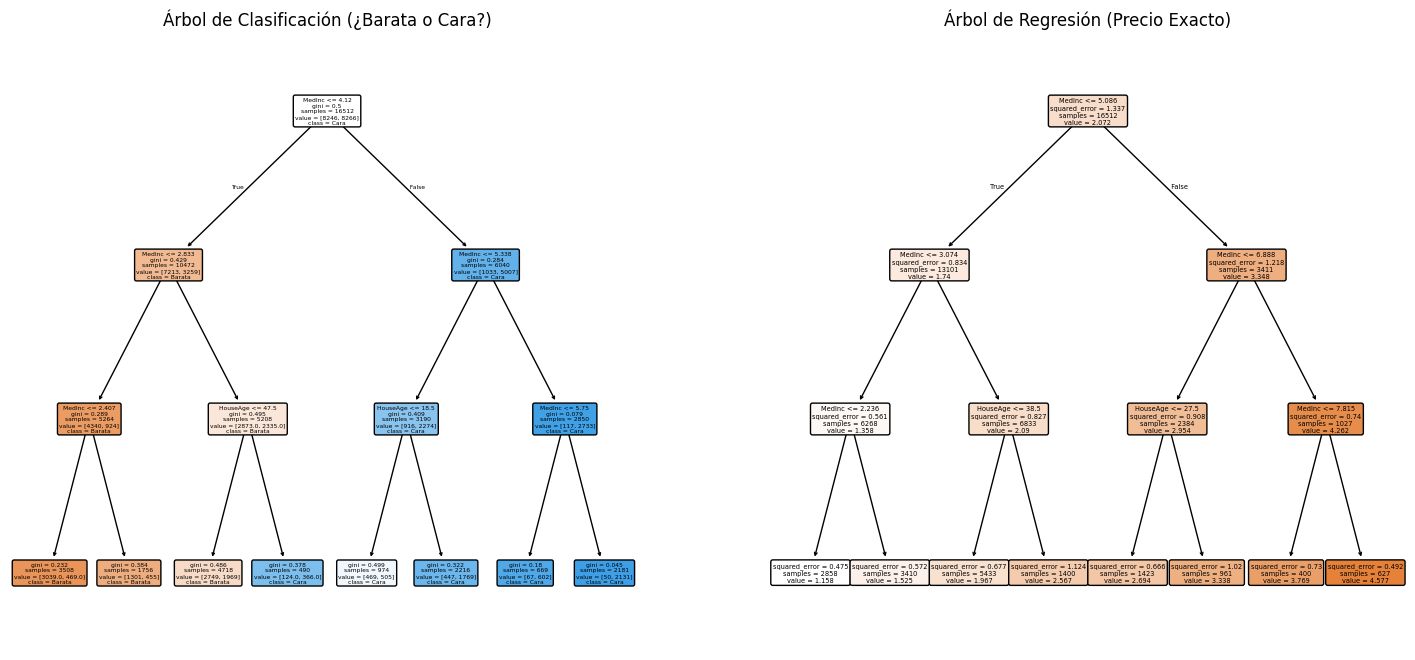

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split

# --- SOLUCIÓN INTEGRADA PARA EL KEYERROR ---
# Cargamos el dataset y manejamos dinámicamente el nombre de la columna objetivo
raw_housing = fetch_california_housing(as_frame=True)
df = raw_housing.frame

# Si la columna se llama 'target', la renombramos a 'MedHouseValue' para mantener tu lógica intacta
actual_target_name = raw_housing.target_names[0]
if actual_target_name != "MedHouseValue":
    df = df.rename(columns={actual_target_name: "MedHouseValue"})
# -------------------------------------------

# Seleccionamos las variables para la interpretación
X = df[["MedInc", "HouseAge"]]
y_continuo = df["MedHouseValue"]  # Ahora esta columna siempre va a existir

# Crear la variable objetivo para CLASIFICACIÓN (Binaria: barata = 0, cara = 1)
mediana_precio = y_continuo.median()
y_categorico = (y_continuo > mediana_precio).astype(int)

# Dividir en conjuntos de entrenamiento y prueba (se corrigió también el parámetro a test_size)
X_train, X_test, y_train_clf, y_test_clf = train_test_split(X, y_categorico, test_size=0.2, random_state=42)
_, _, y_train_reg, y_test_reg = train_test_split(X, y_continuo, test_size=0.2, random_state=42)

# Entrenar Árbol de Clasificación
clf_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_tree.fit(X_train, y_train_clf)

# Entrenar Árbol de Regresión
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
reg_tree.fit(X_train, y_train_reg)

# Visualización de las estructuras de decisión
plt.figure(figsize=(18, 8))

plt.subplot(1, 2, 1)
plot_tree(clf_tree, feature_names=X.columns, class_names=["Barata", "Cara"], filled=True, rounded=True)
plt.title("Árbol de Clasificación (¿Barata o Cara?)")

plt.subplot(1, 2, 2)
plot_tree(reg_tree, feature_names=X.columns, filled=True, rounded=True)
plt.title("Árbol de Regresión (Precio Exacto)")

plt.show()

### 1. ¿Clasificación o Regresión?
* **Clasificación:** Cuando buscás una etiqueta o categoría discreta (Ej: "Cara" o "Barata", "Sí" o "No").
* **Regresión:** Cuando buscás un número exacto y continuo (Ej: El precio real de la casa, como $250.000).

### 2. Impacto de la Profundidad
* **Muy corto:** No aprende nada (**Underfitting**).
* **Muy largo:** Memoriza el ruido de entrenamiento y falla con datos nuevos (**Overfitting**).
* **El objetivo:** Encontrar el punto medio (`max_depth`) para que el modelo generalice bien.

### 3. Cómo mejorar con más atributos
* **Filtrar:** Quedarse solo con las variables que aporten valor real (`feature_importances_`) y borrar el ruido.
* **Evolucionar el algoritmo:** Pasar de un solo árbol a modelos de ensamble (**Random Forest** o **XGBoost**), que combinan cientos de árboles para dar una predicción mucho más precisa.

### Ejercicio para la Sección 2
Instrucciones:

- Cargar el dataset sns.load_dataset("penguins").
- Aplicar un árbol ID3 (criterion="entropy") para predecir la especie del pingüino.
- Aplicar un árbol CART (criterion="gini") con los mismos datos.
- Comparar las precisiones de ambos modelos.

In [8]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Cargar dataset de pingüinos
df = sns.load_dataset("penguins").dropna()

# Preprocesamiento
X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y = df["species"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelos
tree_id3 = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
tree_id3.fit(X_train, y_train)
tree_cart = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)
tree_cart.fit(X_train, y_train)

# Evaluar modelos
print("Precisión ID3:", accuracy_score(y_test, tree_id3.predict(X_test)))
print("Precisión CART:", accuracy_score(y_test, tree_cart.predict(X_test)))


Precisión ID3: 0.9850746268656716
Precisión CART: 0.9850746268656716


### Actividad: Evaluación de un Árbol de Clasificación en Python

Precisión del Árbol de Decisión: 0.9850746268656716

Matriz de Confusión:
 [[30  1  0]
 [ 0 13  0]
 [ 0  0 23]]

Reporte de Clasificación:
               precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        31
   Chinstrap       0.93      1.00      0.96        13
      Gentoo       1.00      1.00      1.00        23

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



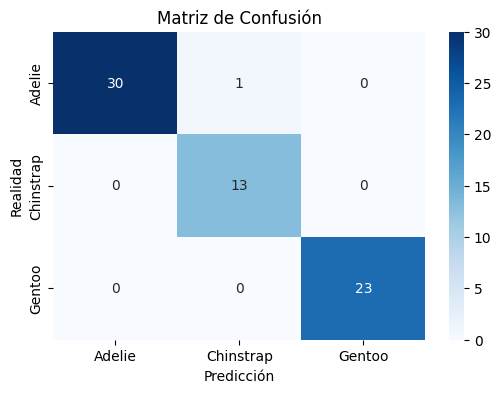

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluación del modelo
y_pred = tree_cart.predict(X_test)
print("Precisión del Árbol de Decisión:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

# Visualización de la matriz de confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=y.unique(), yticklabels=y.unique())
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.title("Matriz de Confusión")
plt.show()


### Actividad para la Sección 3

- Objetivo: Optimizar un Árbol de Decisión para mejorar su desempeño.

Instrucciones:

- Cargar el dataset de "diabetes" (sns.load_dataset("diabetes")).
- Entrenar un árbol de decisión estándar y medir su precisión.
- Optimizar max_depth y min_samples_split usando GridSearchCV.
- Comparar el desempeño del modelo original vs. el optimizado.

In [13]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ["pregnancies", "glucose", "blood_pressure", "skin_thickness", "insulin", "bmi", "pedigree", "age", "outcome"]
mock_diabetes = pd.read_csv(url, names=columns)

sns.load_dataset = lambda name: mock_diabetes if name == "diabetes" else None

# Cargar dataset
df = sns.load_dataset("diabetes").dropna()

# Seleccionar variables
X = df.drop(columns=["outcome"])
y = df["outcome"]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar árbol básico
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
print("Precisión Árbol Básico:", accuracy_score(y_test, tree.predict(X_test)))

# Optimizar con GridSearchCV
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10, 20]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

# Evaluar modelo optimizado
best_tree = grid_search.best_estimator_
print("Mejores parámetros encontrados:", grid_search.best_params_)
print("Precisión Árbol Optimizado:", accuracy_score(y_test, best_tree.predict(X_test)))


Precisión Árbol Básico: 0.7467532467532467
Mejores parámetros encontrados: {'max_depth': 5, 'min_samples_split': 20}
Precisión Árbol Optimizado: 0.7922077922077922
